#                          Uber NYC Trip Analysis

**This project presents an exploratory data analysis (EDA) of Uber trip data in New York City for April and May 2014. The primary objective is to uncover temporal and spatial patterns in rider behavior that can support operational and business decision-making.**

### 📌 Objectives:
- Understand how Uber trip volume varies by hour, day, and weekday.
- Identify peak demand periods and underutilized time slots.
- Explore geographic patterns of pick-up locations using latitude and longitude data.
- Derive actionable business insights from the data.

## Basic Exploration

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the April 2014 Uber dataset.

april=pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-apr14.csv')


In [3]:
april.shape

(564516, 4)

In [4]:
april.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [5]:
# Display first 10 rows.

april.head(10)

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
5,4/1/2014 0:33:00,40.7383,-74.0403,B02512
6,4/1/2014 0:39:00,40.7223,-73.9887,B02512
7,4/1/2014 0:45:00,40.7620,-73.9790,B02512
8,4/1/2014 0:55:00,40.7524,-73.9960,B02512
9,4/1/2014 1:01:00,40.7575,-73.9846,B02512


In [6]:
# What columns are present?

april.columns


Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [7]:
# Convert Date/Time column to datetime.
april['Date/Time']=pd.to_datetime(april['Date/Time'])

april['Date/Time'].dtype


dtype('<M8[ns]')

In [8]:
# Extract hour, day, weekday from Date/Time.
april['hour']=april['Date/Time'].dt.hour
april['day']=april['Date/Time'].dt.day
april['weekday']=april['Date/Time'].dt.day_name()

april.sample(5,random_state=10)

,Date/Time,Lat,Lon,Base,hour,day,weekday
507728,2014-04-25 17:21:00,40.7251,-74.0057,B02682,17,25,Friday
351979,2014-04-04 09:34:00,40.7141,-73.9902,B02682,9,4,Friday
144077,2014-04-21 19:09:00,40.7576,-73.9713,B02598,19,21,Monday
368783,2014-04-05 22:14:00,40.6871,-73.9364,B02682,22,5,Saturday
194056,2014-04-28 15:42:00,40.7412,-73.9983,B02598,15,28,Monday


In [9]:
# What’s the shape of the data?
april.shape


(564516, 7)

In [10]:
# Are there any missing values?
april.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
hour         0
day          0
weekday      0
dtype: int64

## Concatenation

In [11]:
# Load May 2014 Uber dataset 

may=pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-may14.csv')


In [12]:
may.head(5)

,Date/Time,Lat,Lon,Base
0,5/1/2014 0:02:00,40.7521,-73.9914,B02512
1,5/1/2014 0:06:00,40.6965,-73.9715,B02512
2,5/1/2014 0:15:00,40.7464,-73.9838,B02512
3,5/1/2014 0:17:00,40.7463,-74.0011,B02512
4,5/1/2014 0:17:00,40.7594,-73.9734,B02512


In [13]:
may.shape

(652435, 4)

In [14]:
may['Date/Time']=pd.to_datetime(may['Date/Time'])
may['hour']=may['Date/Time'].dt.hour
may['day']=may['Date/Time'].dt.day
may['weekday']=may['Date/Time'].dt.day_name()

In [15]:
# Concatenate April and May datasets vertically.Reset index after concatenation.
# Add a column Month for each row.

april['month']=april['Date/Time'].dt.month_name()
may['month']=may['Date/Time'].dt.month_name()


april_may=pd.concat([april,may],ignore_index=True)
april_may.shape

(1216951, 8)

In [16]:
april_may[april_may['month']=='May']

,Date/Time,Lat,Lon,Base,hour,day,weekday,month
564516,2014-05-01 00:02:00,40.7521,-73.9914,B02512,0,1,Thursday,May
564517,2014-05-01 00:06:00,40.6965,-73.9715,B02512,0,1,Thursday,May
564518,2014-05-01 00:15:00,40.7464,-73.9838,B02512,0,1,Thursday,May
564519,2014-05-01 00:17:00,40.7463,-74.0011,B02512,0,1,Thursday,May
564520,2014-05-01 00:17:00,40.7594,-73.9734,B02512,0,1,Thursday,May
...,...,...,...,...,...,...,...,...
1216946,2014-05-31 23:45:00,40.7309,-74.0014,B02764,23,31,Saturday,May
1216947,2014-05-31 23:52:00,40.7528,-73.9798,B02764,23,31,Saturday,May
1216948,2014-05-31 23:55:00,40.7158,-73.9519,B02764,23,31,Saturday,May
1216949,2014-05-31 23:56:00,40.6961,-73.8997,B02764,23,31,Saturday,May


In [17]:
# Group by Month and count trips.

april_may.groupby('month').size()


month
April    564516
May      652435
dtype: int64

## Merging Datasets

In [18]:
april_may['Base'].unique()


array(['B02512', 'B02598', 'B02617', 'B02682', 'B02764'], dtype=object)

In [19]:
# Create a sample DataFrame with base zones and boroughs:

zone_data=pd.DataFrame({'Base': ['B02512', 'B02598', 'B02617'],
                        
                        'Borough': ['Manhattan', 'Queens', 'Brooklyn']
                        })

In [20]:
# Merge it with the April+May Uber data on Base.

april_may_merged=pd.merge(april_may,zone_data,on='Base',how='outer')
april_may_merged


,Date/Time,Lat,Lon,Base,hour,day,weekday,month,Borough
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April,Manhattan
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April,Manhattan
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April,Manhattan
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April,Manhattan
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April,Manhattan
...,...,...,...,...,...,...,...,...,...
1216946,2014-05-31 23:45:00,40.7309,-74.0014,B02764,23,31,Saturday,May,NaN
1216947,2014-05-31 23:52:00,40.7528,-73.9798,B02764,23,31,Saturday,May,NaN
1216948,2014-05-31 23:55:00,40.7158,-73.9519,B02764,23,31,Saturday,May,NaN
1216949,2014-05-31 23:56:00,40.6961,-73.8997,B02764,23,31,Saturday,May,NaN


In [21]:
# How many trips per borough?

april_may_merged.groupby('Borough').size()



Borough
Brooklyn     230735
Manhattan     72301
Queens       443812
dtype: int64

In [22]:
# another

april_may_merged['Borough'].value_counts()


Borough
Queens       443812
Brooklyn     230735
Manhattan     72301
Name: count, dtype: int64

In [23]:
# Merge only those bases that exist in both.

april_may_merged_with_common_base=pd.merge(april_may,zone_data,on='Base',how='inner')
april_may_merged_with_common_base

,Date/Time,Lat,Lon,Base,hour,day,weekday,month,Borough
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April,Manhattan
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April,Manhattan
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April,Manhattan
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April,Manhattan
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April,Manhattan
...,...,...,...,...,...,...,...,...,...
746843,2014-05-31 23:59:00,40.7270,-73.9912,B02617,23,31,Saturday,May,Brooklyn
746844,2014-05-31 23:59:00,41.0545,-74.0693,B02617,23,31,Saturday,May,Brooklyn
746845,2014-05-31 23:59:00,40.7033,-73.9262,B02617,23,31,Saturday,May,Brooklyn
746846,2014-05-31 23:59:00,40.7304,-74.0001,B02617,23,31,Saturday,May,Brooklyn


In [24]:
# Do a left merge, what happens with missing Boroughs?

left_join=pd.merge(april_may,zone_data,how='left')
left_join

,Date/Time,Lat,Lon,Base,hour,day,weekday,month,Borough
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April,Manhattan
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April,Manhattan
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April,Manhattan
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April,Manhattan
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April,Manhattan
...,...,...,...,...,...,...,...,...,...
1216946,2014-05-31 23:45:00,40.7309,-74.0014,B02764,23,31,Saturday,May,NaN
1216947,2014-05-31 23:52:00,40.7528,-73.9798,B02764,23,31,Saturday,May,NaN
1216948,2014-05-31 23:55:00,40.7158,-73.9519,B02764,23,31,Saturday,May,NaN
1216949,2014-05-31 23:56:00,40.6961,-73.8997,B02764,23,31,Saturday,May,NaN


In [25]:
left_join['Borough'].isnull().sum()

470103

In [26]:
# Do an outer merge and count how many NaN in Borough.
april_may_merged=pd.merge(april_may,zone_data,on='Base',how='outer')
april_may_merged['Borough'].isna().sum()

470103

## Advanced Indexing

In [27]:
# Set Date/Time as index.
april_may['Date/Time'] = pd.to_datetime(april_may['Date/Time'])
april_may.set_index('Date/Time', inplace=True)  
april_may = april_may.sort_index()


In [28]:
# Slice all trips between April 15 and April 20.

df_slice = april_may['2014-04-15':'2014-04-20']
df_slice


,Lat,Lon,Base,hour,day,weekday,month
Date/Time,,,,,,,
2014-04-15 00:00:00,40.7362,-73.9977,B02682,0,15,Tuesday,April
2014-04-15 00:00:00,40.6444,-73.7834,B02682,0,15,Tuesday,April
2014-04-15 00:01:00,40.7176,-73.9580,B02682,0,15,Tuesday,April
2014-04-15 00:01:00,40.7166,-74.0039,B02598,0,15,Tuesday,April
2014-04-15 00:01:00,40.7262,-73.9864,B02682,0,15,Tuesday,April
...,...,...,...,...,...,...,...
2014-04-20 23:59:00,40.7571,-73.9899,B02598,23,20,Sunday,April
2014-04-20 23:59:00,40.7318,-73.9854,B02617,23,20,Sunday,April
2014-04-20 23:59:00,40.6933,-73.9113,B02682,23,20,Sunday,April


In [29]:
# Resample by day and count trips.
daily_trips=april_may.resample('D').size()
daily_trips

Date/Time
2014-04-01    14546
2014-04-02    17474
2014-04-03    20701
2014-04-04    26714
2014-04-05    19521
              ...  
2014-05-27    17004
2014-05-28    22240
2014-05-29    24930
2014-05-30    24413
2014-05-31    21261
Freq: D, Length: 61, dtype: int64

In [30]:
#Resample by hour and get the average trips.
hourly_avg1 = april_may.resample('h').size().mean()
hourly_avg1


831.2506830601093

In [31]:
# What day had the most Uber trips?
daily_trips.idxmax(),daily_trips.max()

(Timestamp('2014-04-30 00:00:00'), 36251)

In [32]:
# What time of day is busiest?

hourly = april_may.groupby(april_may.index.hour).size()
busiest_hour = hourly.idxmax(), hourly.max()
busiest_hour 

(17, 96983)

🔹 What is april_may.index.hour?


DataFrame april_may has a DatetimeIndex (i.e., Date/Time is the index).

(.index.hour extracts the hour part (0 to 23) from each datetime.)


📌 So you’re grouping data by hour of the day, not by date.

In [33]:
# Create a rolling average of trips per day (window=3)

rolling_avg = daily_trips.rolling(window=3).mean()
rolling_avg

Date/Time
2014-04-01             NaN
2014-04-02             NaN
2014-04-03    17573.666667
2014-04-04    21629.666667
2014-04-05    22312.000000
                  ...     
2014-05-27    12682.333333
2014-05-28    16482.000000
2014-05-29    21391.333333
2014-05-30    23861.000000
2014-05-31    23534.666667
Freq: D, Length: 61, dtype: float64

**A rolling average (also called moving average) is a technique used to smooth out short-term fluctuations and highlight longer-term trends in time series data.**

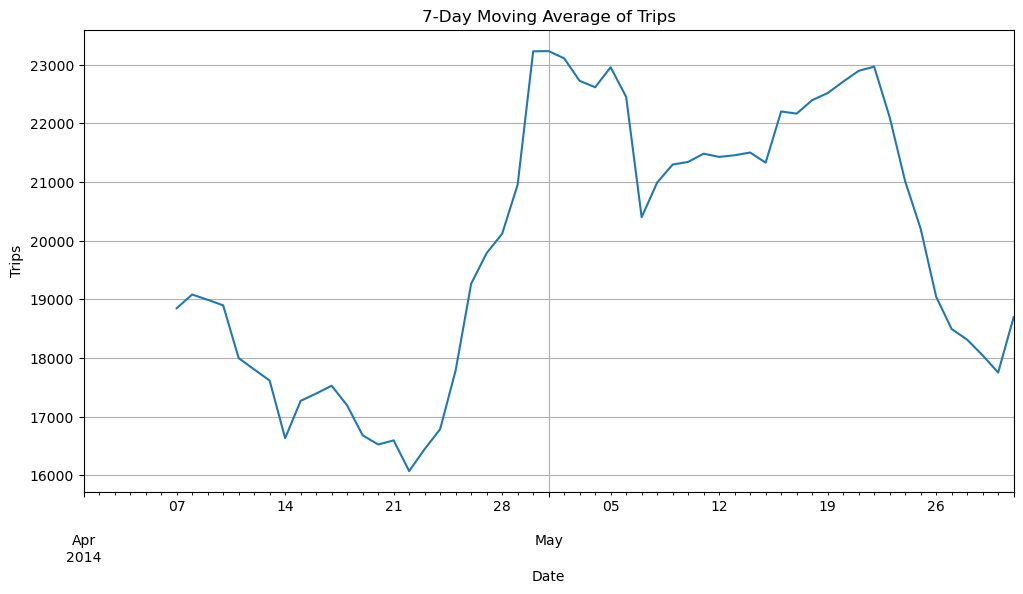

In [34]:
# Create a 7-day moving average plot.

daily_trips.rolling(7).mean().plot(title='7-Day Moving Average of Trips', figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Trips")
plt.grid()
plt.show()

##  Insight: 7-Day Moving Average of Trips

This graph shows the **7-day moving average** of Uber trips during **April to May 2014**.

###  What is a Moving Average?
A **7-day moving average** smooths out daily fluctuations by showing the average number of trips over the previous 7 days.  
This helps reveal **clear trends** in the data without getting distracted by daily noise.

---

###  Axis Details
- **X-axis (Date):** From April 1 to May 31, 2014
- **Y-axis (Trips):** Number of Uber trips per day (smoothed using a 7-day window)

---

###  Key Insights from the Chart

#### 🟦 Phase 1: Early April to April 22
- Trips are relatively **low and stable** (around 16,000 to 18,500)
- Possible reasons: regular weekday demand, fewer users, or seasonal patterns

#### 🟨 Phase 2: April 23 to May 2
- **Sharp spike** in average trips
- From ~17,000 to over 23,000 in a few days
- Likely due to **special events, increased demand, or promotions**

#### 🟩 Phase 3: May 3 to May 21
- Trips remain **consistently high** (above 22,000)
- This is the **peak period** for Uber during this time window

#### 🟥 Phase 4: After May 21
- **Decline** in average trips
- May indicate the end of a promotional period, demand drop, or return to normal levels

---

### ✅ Conclusion
The 7-day moving average highlights key patterns:
- A clear **growth spike** in late April,
- **Strong performance** in early to mid-May,
- Followed by a **decline** in the last week of May.

This technique is valuable for analyzing time series data with **reduced noise and better visibility** of trends.


## Geo-based Filtering

In [35]:
# How many trips had pickup latitude > 40.8?
(april_may['Lat']>40.8).sum()


26529

In [36]:
# Filter for pickups within Manhattan (lat 40.70-40.85 and lon -74 to -73.9).
manhattan_trips =april_may[(april_may['Lat'].between(40.70,40.85)) & (april_may['Lon'].between(-74, -73.9) )]

manhattan_trips

,Lat,Lon,Base,hour,day,weekday,month
Date/Time,,,,,,,
2014-04-01 00:00:00,40.7215,-73.9952,B02682,0,1,Tuesday,April
2014-04-01 00:00:00,40.7188,-73.9863,B02598,0,1,Tuesday,April
2014-04-01 00:00:00,40.7637,-73.9600,B02598,0,1,Tuesday,April
2014-04-01 00:01:00,40.7355,-73.9966,B02617,0,1,Tuesday,April
2014-04-01 00:02:00,40.7556,-73.9874,B02598,0,1,Tuesday,April
...,...,...,...,...,...,...,...
2014-05-31 23:59:00,40.7208,-73.9958,B02682,23,31,Saturday,May
2014-05-31 23:59:00,40.7225,-73.9918,B02682,23,31,Saturday,May
2014-05-31 23:59:00,40.7681,-73.9568,B02682,23,31,Saturday,May


In [37]:

# Create a new column Region: ‘Manhattan’, ‘Other’ based on coordinates.

april_may['Region'] = np.where(
    (april_may['Lat'].between(40.70, 40.85)) & (april_may['Lon'].between(-74, -73.9)),
    'Manhattan', 'Other')

april_may.sample(10)

,Lat,Lon,Base,hour,day,weekday,month,Region
Date/Time,,,,,,,,
2014-05-21 18:26:00,40.7492,-74.0031,B02598,18,21,Wednesday,May,Other
2014-05-30 18:38:00,40.7149,-74.0052,B02682,18,30,Friday,May,Other
2014-05-09 22:03:00,40.7287,-73.9759,B02598,22,9,Friday,May,Manhattan
2014-04-27 19:41:00,40.7731,-73.8856,B02682,19,27,Sunday,April,Other
2014-05-10 00:45:00,40.7448,-73.9934,B02682,0,10,Saturday,May,Manhattan
2014-04-17 14:32:00,40.7250,-73.9982,B02682,14,17,Thursday,April,Manhattan
2014-04-01 18:15:00,40.6887,-73.9853,B02682,18,1,Tuesday,April,Other
2014-05-15 03:06:00,40.7598,-73.9606,B02682,3,15,Thursday,May,Manhattan
2014-05-07 15:42:00,40.7739,-73.9584,B02617,15,7,Wednesday,May,Manhattan


In [38]:
# Count trips by Region.

april_may['Region'].value_counts()

Region
Manhattan    808695
Other        408256
Name: count, dtype: int64

## Grouping & Aggregation

In [39]:
# Group by Base and get trip counts.

april_may.groupby('Base').size()

Base
B02512     72301
B02598    443812
B02617    230735
B02682    450691
B02764     19412
dtype: int64

In [40]:

# Group by weekday and Base.

april_may.groupby(['weekday','Base']).size()



weekday    Base  
Friday     B02512    12965
           B02598    81999
           B02617    42970
           B02682    82997
           B02764     3363
Monday     B02512     7701
           B02598    45304
           B02617    23248
           B02682    46456
           B02764     1998
Saturday   B02512    10169
           B02598    68145
           B02617    32398
           B02682    66573
           B02764     2923
Sunday     B02512     6258
           B02598    39683
           B02617    20051
           B02682    39778
           B02764     1649
Thursday   B02512    12665
           B02598    77113
           B02617    41478
           B02682    79294
           B02764     3438
Tuesday    B02512    10532
           B02598    59927
           B02617    32174
           B02682    62468
           B02764     2746
Wednesday  B02512    12011
           B02598    71641
           B02617    38416
           B02682    73125
           B02764     3295
dtype: int64

In [41]:
#  Group by Region and get average latitude.
april_may.groupby('Region')['Lat'].mean()




Region
Manhattan    40.751452
Other        40.717438
Name: Lat, dtype: float64

In [42]:
# Pivot table of trips by Base and weekday.
pivot=april_may.reset_index().pivot_table(index='weekday',columns='Base',aggfunc='size', fill_value=0)

pivot



Base,B02512,B02598,B02617,B02682,B02764
weekday,,,,,
Friday,12965,81999,42970,82997,3363
Monday,7701,45304,23248,46456,1998
Saturday,10169,68145,32398,66573,2923
Sunday,6258,39683,20051,39778,1649
Thursday,12665,77113,41478,79294,3438
Tuesday,10532,59927,32174,62468,2746
Wednesday,12011,71641,38416,73125,3295


In [43]:
weekday_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# Convert index to a categorical type with ordered days
pivot.index = pd.CategoricalIndex(pivot.index, categories=weekday_order, ordered=True)

# Sort the index
pivot = pivot.sort_index()

pivot

Base,B02512,B02598,B02617,B02682,B02764
weekday,,,,,
Sunday,6258,39683,20051,39778,1649
Monday,7701,45304,23248,46456,1998
Tuesday,10532,59927,32174,62468,2746
Wednesday,12011,71641,38416,73125,3295
Thursday,12665,77113,41478,79294,3438
Friday,12965,81999,42970,82997,3363
Saturday,10169,68145,32398,66573,2923


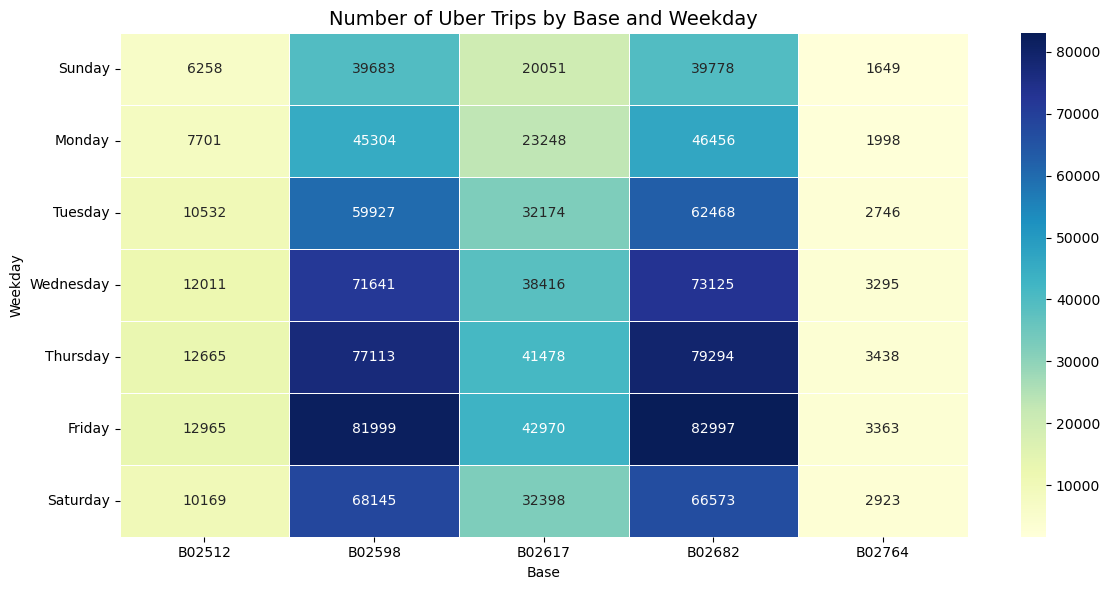

In [44]:
# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("Number of Uber Trips by Base and Weekday", fontsize=14)
plt.xlabel("Base")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

## Insight:  Trips by Base and Weekday

This heatmap visualizes the **number of Uber trips** for each base across weekdays during April–May 2014.

### 🔍 What It Shows:
- **X-axis:** Uber Base (B02512, B02598, etc.)
- **Y-axis:** Days of the week (Sunday to Saturday)
- **Color Intensity + Numbers:** Higher number of trips = darker color

---

###  Key Insights:

1. **B02682 and B02598** consistently show the **highest volume** of trips throughout the week.
2. **Friday and Thursday** are the **busiest weekdays**, especially for bases B02598 and B02682.
3. **Sunday and Monday** generally show **lower activity**, indicating possible reduced demand.
4. **Base B02764** handles the **least number of trips** among all bases every day.
5. The pattern of increased activity from **Tuesday to Friday** may align with weekday commuting and business travel trends.

---

### ✅ Business Takeaway:
- Uber may consider deploying **more drivers for B02682 and B02598** bases on **Fridays and Thursdays**.
- Promotions or marketing on **Sundays and Mondays** could help balance out demand.



In [45]:
# Unstack and restack a groupby object.
grouped = april_may.groupby(['weekday', 'Base']).size()

unstacked=grouped.unstack()
unstacked

Base,B02512,B02598,B02617,B02682,B02764
weekday,,,,,
Friday,12965,81999,42970,82997,3363
Monday,7701,45304,23248,46456,1998
Saturday,10169,68145,32398,66573,2923
Sunday,6258,39683,20051,39778,1649
Thursday,12665,77113,41478,79294,3438
Tuesday,10532,59927,32174,62468,2746
Wednesday,12011,71641,38416,73125,3295


In [46]:
restack=unstacked.stack()
restack

weekday    Base  
Friday     B02512    12965
           B02598    81999
           B02617    42970
           B02682    82997
           B02764     3363
Monday     B02512     7701
           B02598    45304
           B02617    23248
           B02682    46456
           B02764     1998
Saturday   B02512    10169
           B02598    68145
           B02617    32398
           B02682    66573
           B02764     2923
Sunday     B02512     6258
           B02598    39683
           B02617    20051
           B02682    39778
           B02764     1649
Thursday   B02512    12665
           B02598    77113
           B02617    41478
           B02682    79294
           B02764     3438
Tuesday    B02512    10532
           B02598    59927
           B02617    32174
           B02682    62468
           B02764     2746
Wednesday  B02512    12011
           B02598    71641
           B02617    38416
           B02682    73125
           B02764     3295
dtype: int64

## String Operations

In [47]:
# Add a prefix to all column names: "Uber_".

april_may.columns = ['Uber_' + col if col != 'Region' else col for col in april_may.columns]

april_may.columns

Index(['Uber_Lat', 'Uber_Lon', 'Uber_Base', 'Uber_hour', 'Uber_day',
       'Uber_weekday', 'Uber_month', 'Region'],
      dtype='object')

In [48]:
# Rename Uber_Base back to just Base.

april_may.rename(columns={'Uber_Base':'Base'},inplace=True)


In [49]:
# Create column Hour_Label: ‘Morning’, ‘Evening’, etc. based on time.

def hour_label(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

april_may['Hour_Label'] = april_may.index.hour.map(hour_label)
april_may[['Hour_Label']].sample(10)

,Hour_Label
Date/Time,
2014-04-16 22:51:00,Night
2014-05-28 21:05:00,Night
2014-05-22 17:06:00,Evening
2014-05-19 07:19:00,Morning
2014-05-27 12:22:00,Afternoon
2014-05-08 19:48:00,Evening
2014-05-01 20:11:00,Evening
2014-05-15 22:13:00,Night
2014-04-21 14:39:00,Afternoon


In [50]:
# Create Weekend column: True if trip was on Sat or Sun.

april_may['Weekend']=april_may.index.weekday> 5

april_may[['Weekend']].sample(10)

,Weekend
Date/Time,
2014-04-11 13:36:00,False
2014-04-28 02:48:00,False
2014-04-11 13:34:00,False
2014-05-01 20:26:00,False
2014-04-24 08:46:00,False
2014-05-13 12:56:00,False
2014-05-02 12:49:00,False
2014-05-09 16:53:00,False
2014-05-08 15:33:00,False


In [51]:
# Create datetime column DayOfWeek_Hour (e.g., "Mon_14").
april_may['DayOfWeek_Hour'] = april_may.index.strftime('%a_%H')

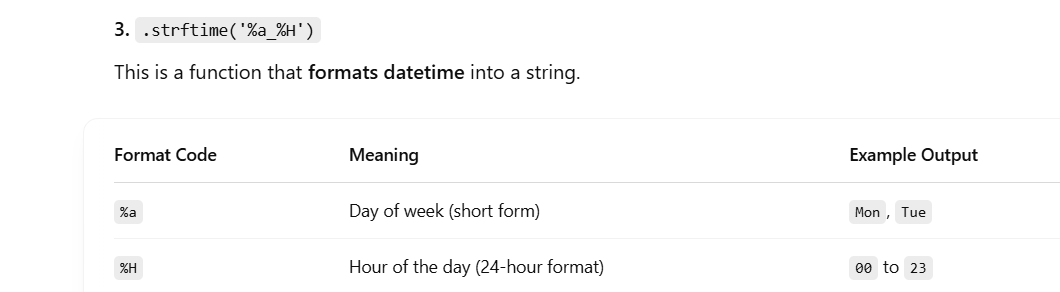

## Analysis

In [52]:
# What's the busiest day of the week?
april_may.index.day_name().value_counts().idxmax()


'Friday'

In [53]:
# What's the least busy hour on average?

april_may.index.day_name().value_counts().idxmin()


'Sunday'

In [54]:
april_may

,Uber_Lat,Uber_Lon,Base,Uber_hour,Uber_day,Uber_weekday,Uber_month,Region,Hour_Label,Weekend,DayOfWeek_Hour
Date/Time,,,,,,,,,,,
2014-04-01 00:00:00,40.7215,-73.9952,B02682,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
2014-04-01 00:00:00,40.7188,-73.9863,B02598,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
2014-04-01 00:00:00,40.7637,-73.9600,B02598,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
2014-04-01 00:01:00,40.7355,-73.9966,B02617,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
2014-04-01 00:02:00,40.7556,-73.9874,B02598,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
...,...,...,...,...,...,...,...,...,...,...,...
2014-05-31 23:59:00,40.7225,-73.9918,B02682,23,31,Saturday,May,Manhattan,Night,False,Sat_23
2014-05-31 23:59:00,40.6171,-74.0209,B02682,23,31,Saturday,May,Other,Night,False,Sat_23
2014-05-31 23:59:00,40.7681,-73.9568,B02682,23,31,Saturday,May,Manhattan,Night,False,Sat_23


### Hourly trip distribution

Text(0.5, 1.0, 'Trip Distribution by Hour')

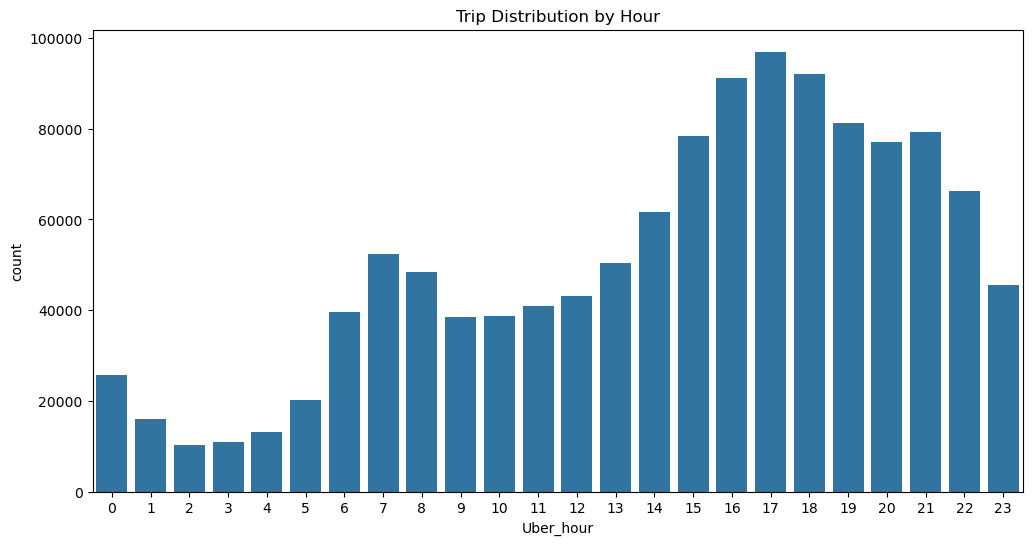

In [55]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Uber_hour', data=april_may)
plt.title('Trip Distribution by Hour')

###  Trip Distribution by Hour – Insights

- **⏰ Peak Hours (Highest Demand):**
  - **5 PM (17:00)** shows the highest trip count, nearing **100,000 trips**.
  - Other peak hours include:
    - **4 PM (16:00)**
    - **6 PM (18:00)**
    - **3 PM (15:00)**
  - This suggests a strong **evening commute trend** as people travel after work.

- **🌅 Morning Rush:**
  - A noticeable spike begins at **6 AM**, with steady increases till **8 AM**, indicating **morning commute traffic**.
  - Moderate usage from **6 AM to 10 AM** suggests work/school-related travel.

- **🌙 Off-Peak Hours (Lowest Demand):**
  - Lowest activity is observed between **2 AM and 5 AM**, where trip counts drop below **15,000**.
  - This reflects typical low demand during late-night/early-morning hours.

- **📉 Late Evening Drop:**
  - After **9 PM (21:00)**, there's a steady decline in trips, especially noticeable at **11 PM (23:00)**.

- **🔄 Midday Stability:**
  - From **10 AM to 1 PM**, trip volumes are fairly consistent, hovering around **40,000–50,000**, possibly due to errands, appointments, and off-peak travel.

---

### 💼 Business Suggestion

To **maximize profitability and customer satisfaction**, Uber can:

- **Incentivize drivers** during high-demand hours (3–6 PM) with surge pricing and bonuses to reduce wait times and meet demand efficiently.
- **Launch targeted promotions** (discount codes or loyalty points) during low-demand hours (2–5 AM) to stimulate usage.
- **Optimize driver scheduling** by aligning supply with peak and off-peak periods to reduce idle time and operational costs.


In [56]:
# Which Base is most active on weekends

april_may[april_may['Weekend']].groupby('Base').size().idxmax()


'B02682'

In [57]:
# How many trips from each base each day?
daily_base=april_may.groupby([april_may.index.date,'Base']).size().unstack(fill_value=0)

daily_base


Base,B02512,B02598,B02617,B02682,B02764
2014-04-01,1011,3738,3219,6255,323
2014-04-02,1336,4526,3752,7515,345
2014-04-03,1482,5499,4254,9061,405
2014-04-04,1827,7151,5387,11865,484
2014-04-05,1309,5508,3691,8640,373
...,...,...,...,...,...
2014-05-27,936,6801,3496,5532,239
2014-05-28,1266,8889,4842,6891,352
2014-05-29,1342,9719,5586,7942,341
2014-05-30,1293,9642,5447,7725,306


In [58]:
# Creating the pivot table of trips from each base per day
pivot_table = april_may.reset_index().pivot_table(
    index=april_may.index.date,   # rows = date
    columns='Base',               # columns = Base
    aggfunc='size',               # values = count of trips
    fill_value=0                  # fill missing values with 0
)

pivot_table

Base,B02512,B02598,B02617,B02682,B02764
2014-04-01,1011,3738,3219,6255,323
2014-04-02,1336,4526,3752,7515,345
2014-04-03,1482,5499,4254,9061,405
2014-04-04,1827,7151,5387,11865,484
2014-04-05,1309,5508,3691,8640,373
...,...,...,...,...,...
2014-05-27,936,6801,3496,5532,239
2014-05-28,1266,8889,4842,6891,352
2014-05-29,1342,9719,5586,7942,341
2014-05-30,1293,9642,5447,7725,306


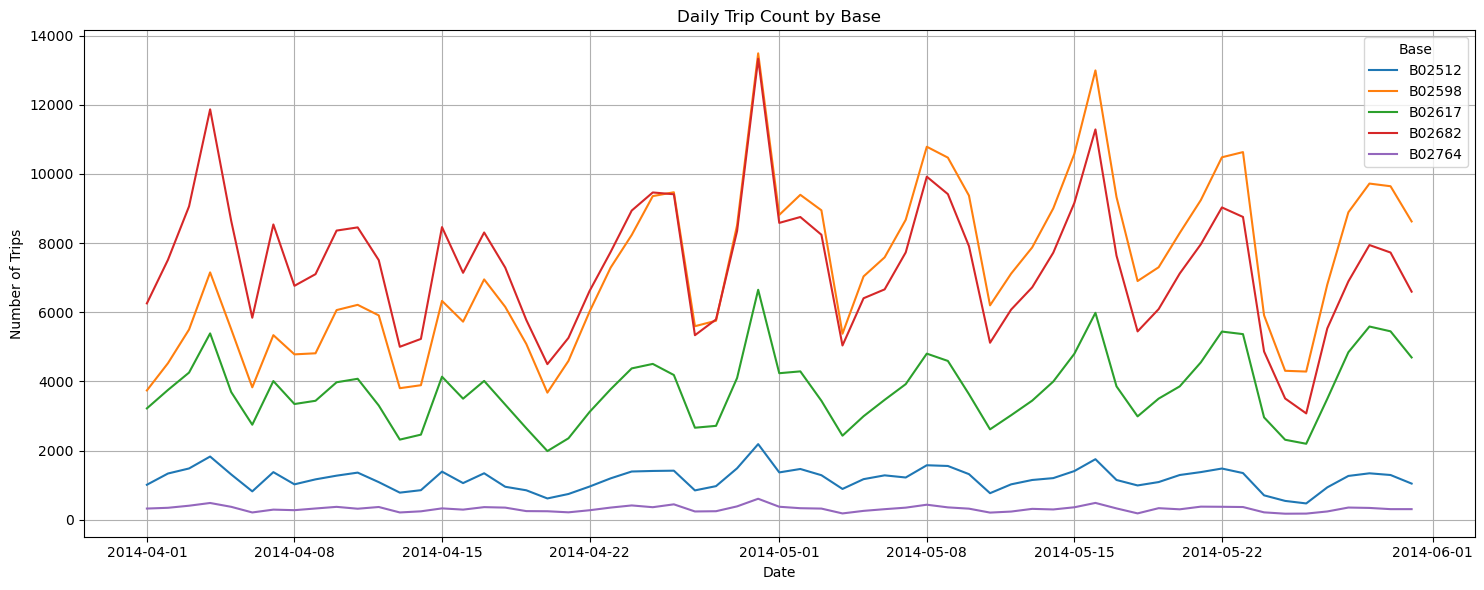

In [59]:
pivot_table.plot(figsize=(15, 6))

plt.title('Daily Trip Count by Base')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.legend(title='Base')
plt.grid(True)
plt.tight_layout()
plt.show()

##  Daily Trip Count by Base (April–May 2014) — Insights

### 🔝 1. Top-Performing Bases
- **B02682** and **B02598** are the most active bases.
- **B02682** shows frequent spikes, exceeding **13,000 trips/day** around **May 1st** and **May 15th**.
- **B02598** also consistently shows high volume, peaking around the same dates.

### 🔻 2. Low Activity Bases
- **B02764** is the least active, consistently below **1000 trips/day**.
- **B02512** also has relatively lower activity, mostly under **2000 trips/day**.

### 📈 3. Weekly Demand Trends
- A noticeable **weekly pattern** is visible — peaks every **7 days**.
- This likely indicates **higher demand on weekends or Fridays**.
- All bases reflect this trend, suggesting a consistent city-wide rider behavior.

### 📆 4. Notable Spikes
- Significant spikes on:
  - **April 3–4**
  - **May 1** *(Labor Day)*
  - **May 15–16*
- These peaks are observed across all major bases.

### 🧘 5. Smoother Trends for Low-Volume Bases
- **B02764** and **B02512** show a smoother, more stable trend.
- This could imply:
  - Smaller fleet or operational area
  - Lower customer base
  - Limited service hours or geographic constraints

---

### 💡 Business Implications

| Insight                        | Implication                                             |
|-------------------------------|----------------------------------------------------------|
| High spikes on weekends       | Introduce **surge pricing** or **deploy more drivers**   |
| B02682 consistently dominates | Allocate more **resources/fleet** to meet demand         |
| Weekly wave patterns          | Helps with **forecasting and scheduling**                |
| Underperforming bases         | Evaluate for **marketing**, **reallocation**, or **cost-efficiency** |

---



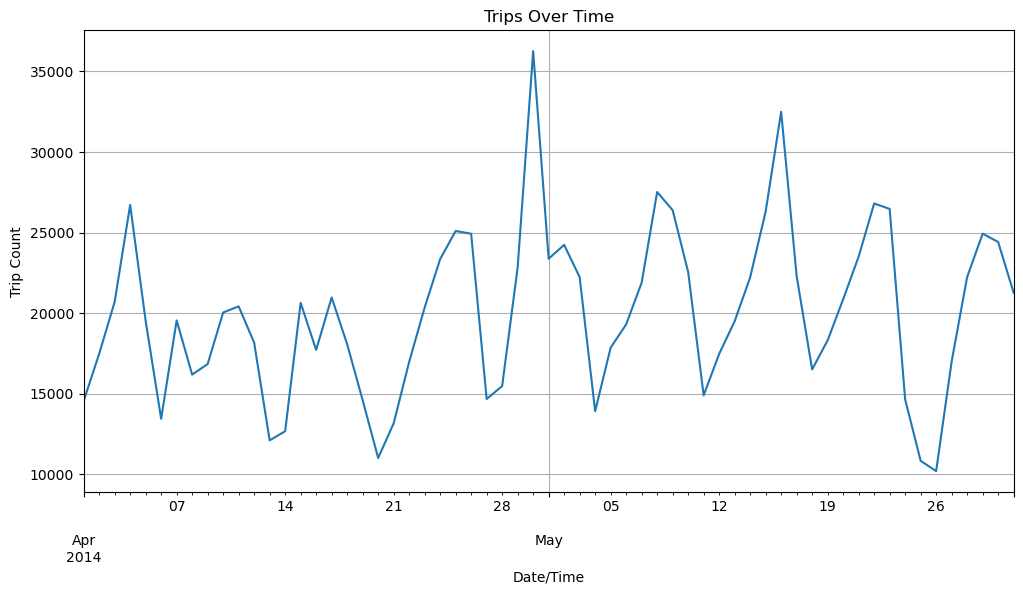

In [60]:
# Plot number of trips over time (line plot)
april_may.resample('D').size().plot(figsize=(12,6), title='Trips Over Time')
plt.ylabel('Trip Count')
plt.grid()
plt.show()

##  Trips Over Time – April & May 2014

### 🔍 Insights from the Line Chart:

1. **General Trend:**
   - The number of trips fluctuates daily, generally staying between **10,000 to 35,000** trips per day.

2. **Peaks in Demand:**
   - A **notable spike** around **April 28th**, reaching over **36,000 trips**—this is the **highest point** in the graph.
   - Other peaks occur at regular intervals, likely **weekends**, showing increased demand.

3. **Regular Dips:**
   - Several **sharp drops** in trip counts occur after each peak, with the lowest counts around **10,000–15,000** trips.
   - These dips likely correspond to **early weekdays** (e.g., Monday or Tuesday).

4. **Weekly Seasonality:**
   - The consistent pattern of peaks and valleys suggests a **weekly cycle** of demand, likely driven by **human behavior** (weekend outings vs. weekday routines).

---

###  Possible Reasons Behind the Pattern:

- **Weekends:** Higher taxi usage due to outings, parties, events, or leisure activities.
- **Events or Holidays:** The significant peak around April 28 may relate to a local event or public holiday.
- **External Factors:** Weather changes or ride-sharing promotions might influence the spike or drop.

---

###  Summary Table:

| Aspect            | Insight                            |
|-------------------|-------------------------------------|
| 📅 Period          | April–May 2014                     |
| 🔺 Highest Trips   | ~36,000 trips (around April 28)    |
| 🔻 Lowest Trips    | ~10,000 trips                      |
| 🔁 Pattern         | Weekly seasonality (weekend peaks) |
| 📌 Behavior Pattern| Weekends & events boost demand     |

---


## Exporting and Importing

In [61]:
#Export April trips to CSV
april.to_csv('Uber_april14',index=False)

In [62]:
# Export May trips to Excel.

may.to_csv('uber_may14',index=False)

In [63]:
# Save base zone summary to JSON.

april_may_reset=april_may.reset_index()
zone_summary=april_may_reset.groupby('Base').size().to_json
zone_summary

<bound method NDFrame.to_json of Base
B02512     72301
B02598    443812
B02617    230735
B02682    450691
B02764     19412
dtype: int64>

In [64]:
# Save entire combined DataFrame as pickle.
april_may_reset.to_pickle('Uber_April_may14.pkl')


In [65]:
# Load the pickle file and verify its contents.
loaded_df = pd.read_pickle('Uber_April_may14.pkl')
loaded_df.head()

,Date/Time,Uber_Lat,Uber_Lon,Base,Uber_hour,Uber_day,Uber_weekday,Uber_month,Region,Hour_Label,Weekend,DayOfWeek_Hour
0,2014-04-01 00:00:00,40.7215,-73.9952,B02682,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
1,2014-04-01 00:00:00,40.7188,-73.9863,B02598,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
2,2014-04-01 00:00:00,40.7637,-73.9600,B02598,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
3,2014-04-01 00:01:00,40.7355,-73.9966,B02617,0,1,Tuesday,April,Manhattan,Night,False,Tue_00
4,2014-04-01 00:02:00,40.7556,-73.9874,B02598,0,1,Tuesday,April,Manhattan,Night,False,Tue_00


## ✅ Final Conclusion

This project provided valuable insights into Uber’s operational patterns in NYC during April and May 2014. By analyzing trip frequency across hours, days, and locations, we identified clear trends in rider behavior.
### 📈 Key Findings:
- Uber usage peaks during **evening hours (4 PM–7 PM)**.
- **Thursday and Friday** are the busiest days.
- Morning and late-night hours show lower activity.
- Trips are densely concentrated in **Manhattan**, suggesting strong demand in central NYC areas.

These insights can drive decisions in driver deployment, pricing strategy, and marketing efforts.

### 💡 Business Implications:
- Dynamic pricing and driver allocation should focus on peak hours.
- Off-peak marketing strategies can be designed to balance usage.


